# Renewable Energy ANN Regression Project

This notebook builds a multilayer perceptron to predict renewable energy output in kWh from weather and time-based features.

It includes:
- data loading and cleaning
- time-based feature engineering
- chronological 70/15/15 split
- MinMax scaling
- ANN training with EarlyStopping
- evaluation with RMSE, MAE, and R²
- a linear regression baseline for comparison

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

OUTPUT_DIR = Path('artifacts')

# Feature columns
FEATURE_COLUMNS = ['Air_Temp', 'Wind_Speed', 'Relative_Humidity', 'hour', 'month']
# Target column to predict
TARGET_COLUMN = 'Solar_Radiation' 

EPOCHS = 150
BATCH_SIZE = 32
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
LEARNING_RATE = 0.001
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load and preprocess data

The dataset is sorted by time, missing values are handled, and time features such as hour and month are extracted from the datetime column.

In [21]:
# The datasets are already provided in the Datasets folder.
dataset_folder = 'Datasets'
print(f"Dataset folder: {dataset_folder}")
import os
for file in os.listdir(dataset_folder):
    print(f"  - {file}")


Dataset folder: Datasets
  - DATARENER.csv
  - Humidity.csv


In [22]:
# Read both CSVs. 
# DATARENER.csv parsing: skip the first 8 lines based on the file content.
df_rener = pd.read_csv("Datasets/DATARENER.csv", skiprows=8) # 8 lines of metadata then headers
print("DATARENER columns:", df_rener.columns.tolist())

df_hum = pd.read_csv("Datasets/Humidity.csv", skiprows=2)
print("Humidity columns:", df_hum.columns.tolist())

# Format DATARENER.csv timestamp
# Format: YYYYMMDD:HHMM
# We use errors='coerce' because the bottom of the CSV contains a footer with text descriptions
df_rener['Timestamp'] = pd.to_datetime(df_rener['time'], format='%Y%m%d:%H%M', errors='coerce')
df_rener = df_rener.dropna(subset=['Timestamp'])

# Round to the nearest hour since the timestamps are at :30 past the hour
df_rener['Timestamp'] = df_rener['Timestamp'].dt.floor('h')

# Format Humidity.csv timestamp
# Format: Year, Month, Day, Hour, Minute
df_hum['Timestamp'] = pd.to_datetime(df_hum[['Year', 'Month', 'Day', 'Hour', 'Minute']])

# Round to the nearest hour to be safe 
df_hum['Timestamp'] = df_hum['Timestamp'].dt.floor('h')

print("\nDATARENER first rows:")
print(df_rener.head(2))

print("\nHumidity first rows:")
print(df_hum.head(2))

DATARENER columns: ['time', 'G(i)', 'H_sun', 'T2m', 'WS10m', 'Int']
Humidity columns: ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Relative Humidity']

DATARENER first rows:
            time    G(i)  H_sun    T2m  WS10m  Int           Timestamp
0  20200101:0030  769.49  29.89  25.96   7.17  0.0 2020-01-01 00:00:00
1  20200101:0130   923.4  41.33  26.80   8.48  0.0 2020-01-01 01:00:00

Humidity first rows:
   Year  Month  Day  Hour  Minute  Relative Humidity           Timestamp
0  2020      1    1     0       0              94.58 2020-01-01 00:00:00
1  2020      1    1     1       0              94.08 2020-01-01 01:00:00


In [ ]:
# Merge the dataframes on the Timestamp column
df = pd.merge(df_rener, df_hum, on='Timestamp', how='inner')

# Rename columns to match what the model expects
df = df.rename(columns={
    'G(i)': 'Solar_Radiation',
    'T2m': 'Air_Temp',
    'WS10m': 'Wind_Speed',
    'Relative Humidity': 'Relative_Humidity'
})

TARGET_COLUMN = 'Solar_Radiation' 

df = df.sort_values('Timestamp').reset_index(drop=True)
df = df.dropna(subset=['Timestamp', TARGET_COLUMN])

df['hour'] = df['Timestamp'].dt.hour
df['month'] = df['Timestamp'].dt.month
df['day_of_week'] = df['Timestamp'].dt.dayofweek

# Mapping months to seasons (1=Winter, 2=Spring, 3=Summer, 4=Fall)
df['season'] = (df['month'] % 12 // 3 + 1)

numeric_columns = ['Solar_Radiation', 'Air_Temp', 'Wind_Speed', 'Relative_Humidity']

# Ensure the columns are numeric before interpolation 
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

df[numeric_columns] = df[numeric_columns].interpolate(method='linear', limit_direction='both')
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median(numeric_only=True))

df.head()


,time,Solar_Radiation,H_sun,Air_Temp,Wind_Speed,Int,Timestamp,Year,Month,Day,Hour,Minute,Relative_Humidity,hour,month,day_of_week
0,20200101:0030,769.49,29.89,25.96,7.17,0.0,2020-01-01 00:00:00,2020,1,1,0,0,94.58,0,1,2
1,20200101:0130,923.40,41.33,26.80,8.48,0.0,2020-01-01 01:00:00,2020,1,1,1,0,94.08,1,1,2
2,20200101:0230,843.03,50.57,27.59,8.83,0.0,2020-01-01 02:00:00,2020,1,1,2,0,94.12,2,1,2
3,20200101:0330,860.96,55.77,28.12,8.69,0.0,2020-01-01 03:00:00,2020,1,1,3,0,94.12,3,1,2
4,20200101:0430,919.93,55.07,28.43,8.55,0.0,2020-01-01 04:00:00,2020,1,1,4,0,93.95,4,1,2


## 2. Chronological split and scaling

The split is time-based, not random, so future observations are never used in training. Inputs and target values are then scaled with MinMaxScaler.

In [24]:
def chronological_split(frame, validation_ratio=0.15, test_ratio=0.15):
    if validation_ratio + test_ratio >= 1:
        raise ValueError('Validation and test ratios must sum to less than 1.')

    total_rows = len(frame)
    test_size = int(round(total_rows * test_ratio))
    validation_size = int(round(total_rows * validation_ratio))
    train_end = total_rows - validation_size - test_size

    if train_end <= 0:
        raise ValueError('Not enough rows to create train/validation/test splits.')

    train_df = frame.iloc[:train_end].copy()
    validation_df = frame.iloc[train_end:train_end + validation_size].copy()
    test_df = frame.iloc[train_end + validation_size:].copy()
    return train_df, validation_df, test_df

train_df, validation_df, test_df = chronological_split(df, VALIDATION_RATIO, TEST_RATIO)

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train = feature_scaler.fit_transform(train_df[FEATURE_COLUMNS])
X_val = feature_scaler.transform(validation_df[FEATURE_COLUMNS])
X_test = feature_scaler.transform(test_df[FEATURE_COLUMNS])

y_train = target_scaler.fit_transform(train_df[[TARGET_COLUMN]])
y_val = target_scaler.transform(validation_df[[TARGET_COLUMN]])
y_test = target_scaler.transform(test_df[[TARGET_COLUMN]])

X_train.shape, X_val.shape, X_test.shape

((6132, 4), (1314, 4), (1314, 4))

## 3. Build the ANN model

The model follows the requested architecture: 10 hidden units, then 8 hidden units, then a linear output neuron for regression.

In [ ]:
def build_ann_model(input_dim, learning_rate=0.001):
    model = keras.Sequential([
        keras.layers.Dense(10, activation='relu', input_shape=(input_dim,)),
        keras.layers.Dropout(0.2), 
        keras.layers.Dense(8, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation='linear')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

ann_model = build_ann_model(len(FEATURE_COLUMNS), learning_rate=LEARNING_RATE)
ann_model.summary()

d:\CodingRelated\Codes.Ams\IS_RENER_PROJ\IS_PROJ\.venv_tf\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147 (588.00 B)

 Trainable params: 147 (588.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Train the ANN

EarlyStopping restores the best weights from validation loss, which helps reduce overfitting.

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

history = ann_model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1968 - mae: 0.3202 - val_loss: 0.0645 - val_mae: 0.1987
Epoch 2/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1126 - mae: 0.2649 - val_loss: 0.0423 - val_mae: 0.1654
Epoch 3/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0611 - mae: 0.1930 - val_loss: 0.0316 - val_mae: 0.1519
Epoch 4/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0318 - mae: 0.1326 - val_loss: 0.0309 - val_mae: 0.1423
Epoch 5/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0279 - mae: 0.1196 - val_loss: 0.0273 - val_mae: 0.1360
Epoch 6/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0261 - mae: 0.1154 - val_loss: 0.0225 - val_mae: 0.1176
Epoch 7/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0250 - mae: 0.1121 - val_loss: 0.0216 - val_mae: 0.1138
Epoch 8/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0242 - mae: 0.1107 - val_loss: 0.0194 - val_mae: 0.1007
Epoch 9/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

## 5. Evaluate the ANN and compare it with linear regression

Metrics are computed on the inverse-transformed test predictions so they are reported in the original kWh scale.

In [27]:
def inverse_target(values):
    return target_scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).reshape(-1)

def evaluate_predictions(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }

y_test_true = inverse_target(y_test)
ann_pred = inverse_target(ann_model.predict(X_test))
ann_metrics = evaluate_predictions(y_test_true, ann_pred)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train.ravel())
baseline_pred = inverse_target(baseline_model.predict(X_test))
baseline_metrics = evaluate_predictions(y_test_true, baseline_pred)

print('ANN metrics:', ann_metrics)
print('Baseline metrics:', baseline_metrics)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
ANN metrics: {'rmse': 149.27303041154312, 'mae': 115.89050070638253, 'r2': 0.8008005538092062}
Baseline metrics: {'rmse': 235.37792202343093, 'mae': 203.6920369240989, 'r2': 0.504713059955928}


## 6. Visualize results and save the trained model

The plots below show training behavior and predicted-vs-actual performance. The trained ANN is also saved to disk as an `.h5` file.

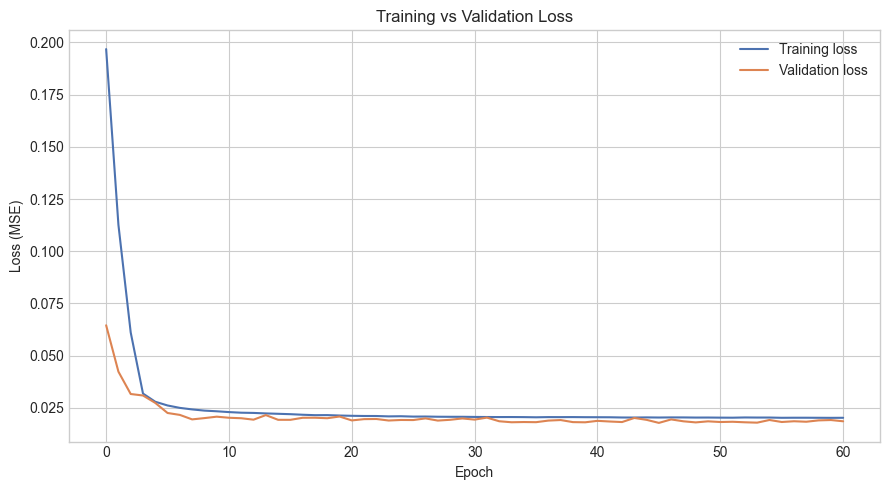

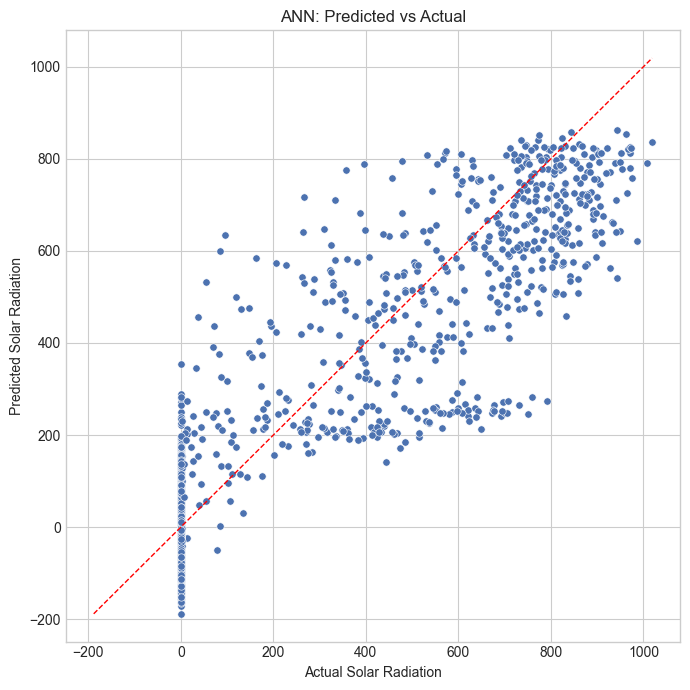

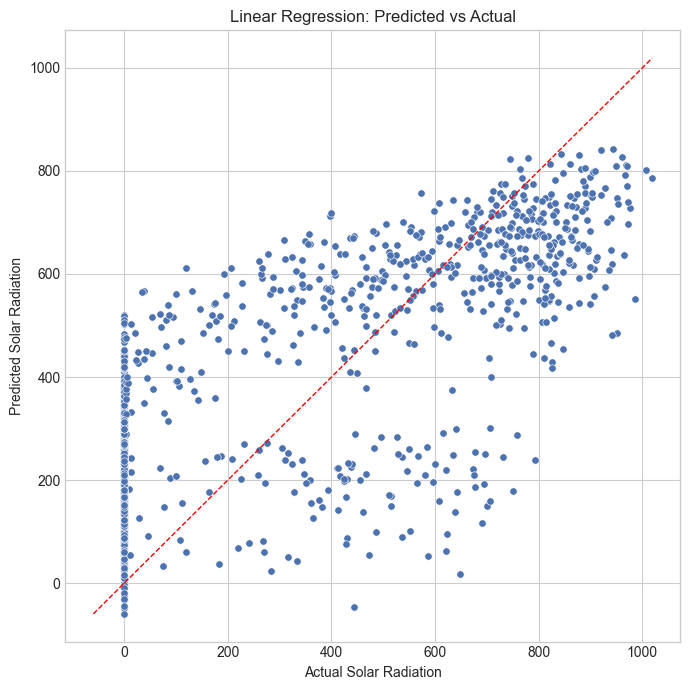

Saved model to artifacts\ann_model.h5


In [28]:
def plot_training_history(history_obj):
    plt.figure(figsize=(9, 5))
    plt.plot(history_obj.history['loss'], label='Training loss')
    if 'val_loss' in history_obj.history:
        plt.plot(history_obj.history['val_loss'], label='Validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_predicted_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true, y=y_pred, s=28)
    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r--', linewidth=1)
    plt.xlabel('Actual Solar Radiation')
    plt.ylabel('Predicted Solar Radiation')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_training_history(history)
plot_predicted_vs_actual(y_test_true, ann_pred, 'ANN: Predicted vs Actual')
plot_predicted_vs_actual(y_test_true, baseline_pred, 'Linear Regression: Predicted vs Actual')

model_path = OUTPUT_DIR / 'ann_model.h5'
ann_model.save(model_path)
print(f'Saved model to {model_path}')

## 7. Summary

- The ANN is the main nonlinear regression model.
- Linear regression provides a simple baseline.
- If validation loss rises while training loss falls, increase regularization or dropout, or reduce model complexity.